# 07 — Period Comparison and Recovery Analysis

This notebook answers the study's main question: **How far did Luzon electricity-demand behavior move away from its pre-pandemic pattern during the pandemic, and how far did it move back afterward?**

The final recovery classification uses normalized 24-hour profiles so that long-term growth in MW does not automatically count as a change in daily-use structure.

In [3]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
if not (project_root / "src" / "data_preparation.py").is_file():
    project_root = project_root.parent
if not (project_root / "src" / "data_preparation.py").is_file():
    raise FileNotFoundError("Run this notebook from the project root or notebooks directory.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import PERIOD_ORDER
figures_dir = project_root / "figures"
results_dir = project_root / "results"
figures_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

from src.comparison import pairwise_profile_rmse, classify_profile_recovery, normalized_period_profiles
from src.eda import period_summary, peak_hour_distribution

df = pd.read_csv(project_root / "data/processed/luzon_hourly_clean.csv", parse_dates=["date", "datetime"])
distances = pairwise_profile_rmse(df)
classification = classify_profile_recovery(df)
distances.round(6)

,period_a,period_b,normalized_profile_rmse
0,Pre-pandemic,Pandemic,0.024776
1,Pandemic,Recovery,0.009986
2,Pre-pandemic,Recovery,0.019760


In [4]:
classification

,classification,pre_vs_pandemic_rmse,pre_vs_recovery_rmse,recovery_to_disruption_ratio,pre_baseline_95pct_tolerance,rationale
0,Partial recovery,0.024776,0.01976,0.797531,0.003972,Recovery is closer to the pre-pandemic profile...


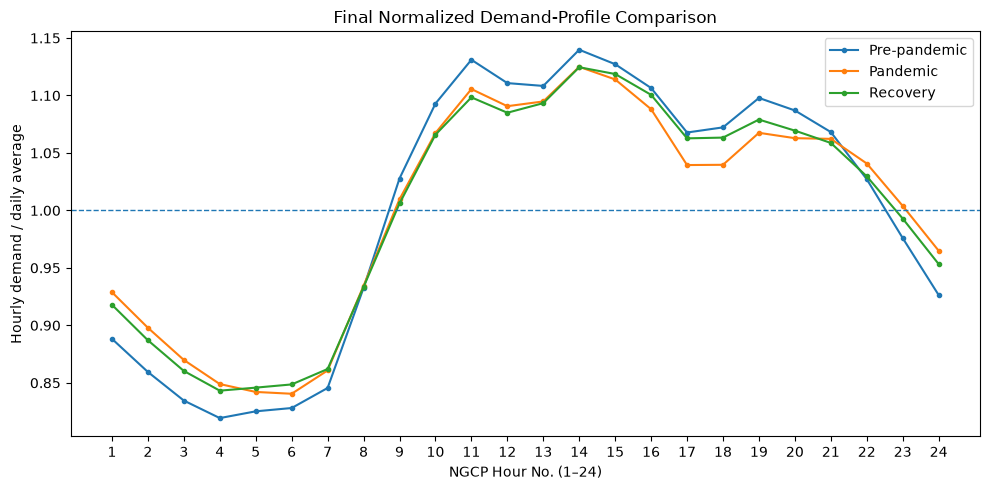

In [5]:
profiles = normalized_period_profiles(df).copy()
profiles["NGCP Hour No."] = profiles["hour"] + 1
plt.figure(figsize=(10, 5))
for period in PERIOD_ORDER:
    p = profiles[profiles["period"] == period]
    plt.plot(p["NGCP Hour No."], p["normalized_demand"], marker="o", markersize=3, label=period)
plt.axhline(1.0, linewidth=1, linestyle="--")
plt.title("Final Normalized Demand-Profile Comparison")
plt.xlabel("NGCP Hour No. (1–24)")
plt.ylabel("Hourly demand / daily average")
plt.xticks(range(1, 25))
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "final_normalized_profile_comparison.png", dpi=160)
plt.show()

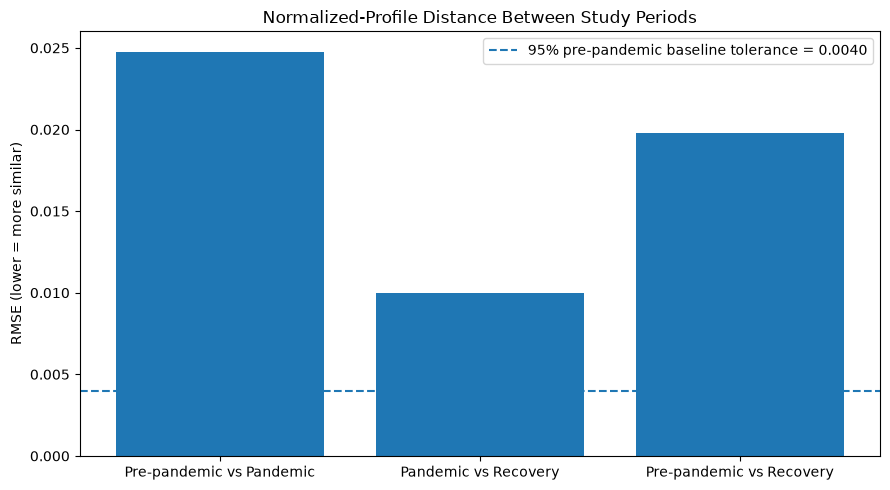

In [6]:
labels = [f"{a} vs {b}" for a, b in zip(distances["period_a"], distances["period_b"])]
values = distances["normalized_profile_rmse"].to_numpy()
tolerance = float(classification["pre_baseline_95pct_tolerance"].iloc[0])
plt.figure(figsize=(9, 5))
plt.bar(labels, values)
plt.axhline(tolerance, linestyle="--", label=f"95% pre-pandemic baseline tolerance = {tolerance:.4f}")
plt.title("Normalized-Profile Distance Between Study Periods")
plt.ylabel("RMSE (lower = more similar)")
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "final_profile_rmse_comparison.png", dpi=160)
plt.show()

In [7]:
summary = period_summary(df).set_index("period").reindex(PERIOD_ORDER)
peaks = peak_hour_distribution(df).copy()
peaks["NGCP Hour No."] = peaks["peak_hour"] + 1
mode_peak = {}
for period in PERIOD_ORDER:
    p = peaks[peaks["period"] == period].sort_values("share", ascending=False).iloc[0]
    mode_peak[period] = (int(p["NGCP Hour No."]), float(p["share"]*100))
context = pd.DataFrame({
    "period": PERIOD_ORDER,
    "mean_demand_MW": [summary.loc[p,"mean_mw"] for p in PERIOD_ORDER],
    "max_demand_MW": [summary.loc[p,"max_mw"] for p in PERIOD_ORDER],
    "most_common_peak_NGCP_Hour_No": [mode_peak[p][0] for p in PERIOD_ORDER],
    "share_days_at_modal_peak_pct": [mode_peak[p][1] for p in PERIOD_ORDER],
})
context.round(2)

,period,mean_demand_MW,max_demand_MW,most_common_peak_NGCP_Hour_No,share_days_at_modal_peak_pct
0,Pre-pandemic,7858.47,11301.0,14,56.80
1,Pandemic,8055.74,11599.0,14,55.54
2,Recovery,9262.99,13957.0,14,51.82


In [8]:
classification.to_csv(results_dir / "recovery_classification.csv", index=False)
distances.to_csv(results_dir / "pairwise_normalized_profile_rmse.csv", index=False)
context.to_csv(results_dir / "final_period_context.csv", index=False)

r = classification.iloc[0]
print("HEADLINE RESULT:", r["classification"].upper())
print(f"Pre-pandemic vs Pandemic RMSE: {r['pre_vs_pandemic_rmse']:.6f}")
print(f"Pre-pandemic vs Recovery RMSE: {r['pre_vs_recovery_rmse']:.6f}")
print(f"Recovery / disruption distance ratio: {r['recovery_to_disruption_ratio']:.3f}")
print(f"95% pre-pandemic internal-variability tolerance: {r['pre_baseline_95pct_tolerance']:.6f}")
print()
print("Interpretation:")
print(r["rationale"])
print()
print("Research boundary: these results establish differences associated with the three historical periods; they do not prove that COVID-19 alone caused every observed change.")

HEADLINE RESULT: PARTIAL RECOVERY
Pre-pandemic vs Pandemic RMSE: 0.024776
Pre-pandemic vs Recovery RMSE: 0.019760
Recovery / disruption distance ratio: 0.798
95% pre-pandemic internal-variability tolerance: 0.003972

Interpretation:
Recovery is closer to the pre-pandemic profile than the pandemic profile was, but remains outside baseline variability.

Research boundary: these results establish differences associated with the three historical periods; they do not prove that COVID-19 alone caused every observed change.


## Presentation takeaway

Use **Partial recovery** as the current headline conclusion **if the outputs above remain unchanged after final reruns**. Explain that recovery-period demand moved closer to the pre-pandemic 24-hour shape than pandemic demand did, but the remaining difference was still much larger than ordinary within-pre-pandemic profile variation. Also keep demand **level** separate from demand **pattern**: recovery-period MW is substantially higher, while the normalized profile is the basis for judging structural return.